# Дообучение Donut на извлечение реквизитов чека

В предыдущем ноутбуке мы измерили baseline и убедились что готовая модель не извлекает реквизиты чека ни в каком виде, по магазину, дате и адресу у неё ноль. Здесь мы это исправляем, дообучая модель на датасете SROIE, где эти поля размечены.

Коротко о том, как обучается Donut. На вход подаётся изображение чека, а на выход модель должна выдать целевую структуру в виде последовательности токенов: наши поля, обёрнутые в специальные теги. Мы показываем модели пятьсот пар изображение-структура из обучающей части SROIE. По ходу обучения следим за качеством на отдельной валидационной части, чтобы не переобучиться.

Стартуем не с чистой модели, а с той же donut-base-finetuned-cord-v2, что измеряли в baseline. Она уже умеет читать текст чеков, ей не хватает лишь умения раскладывать прочитанное по нужным полям. С такой стартовой точки на наших небольших данных обучение идёт быстрее и даёт лучший результат, чем с нуля.

Модель не знает тегов наших новых полей, поэтому их нужно добавить в словарь модели, иначе она физически не сможет их сгенерировать.

Обучение идёт в Colab на GPU. Чекпоинты сохраняем на Google Drive, чтобы при обрыве сессии можно было продолжить с последнего сохранения, а не начинать заново.

## Запуск в Google Colab

Ноутбук я специально подготовила для удобного запуска в Colab без ручных скачиваний.
Код и данные подтягиваются из удалённых источников автоматически.

Важно: если хотите пропустить этап обучения просто поменяйте в ячейке ниже соответствующую перемнную, там помечено комментарием, какую именно. Тогда просто удалённо подтянутся веса нужной модели, вообще все веса итоговых моделей залиты на Google Drive.

In [ ]:
# Настройка окружения для Colab
import os
import sys
import subprocess
from pathlib import Path
import zipfile
import gdown

IN_COLAB = "google.colab" in sys.modules
# Публичный git-репозиторий с кодом проекта.
REPO_URL = "https://github.com/ScarletFlame611/Receipt-AI.git"
# id датасета sroie_donut.zip на Google Drive
SROIE_DONUT_GDRIVE_ID = "10nAlGwwvjI0TLhl0JXusYug_KuqZzvfX"
# id готовых весов Donut
DONUT_WEIGHTS_GDRIVE_ID = "1w4GgDZOhoKr6Q37IpQFL223YaNynL4qp"
# Пропустить обучение и взять готовую модель с Google Drive
SKIP_TRAINING = True


def _find_project_root():
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / "src").is_dir():
            return cand
    for sub in sorted(p for p in here.iterdir() if p.is_dir()):
        if (sub / "src").is_dir():
            return sub
    return None


if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install",
         "transformers", "datasets", "sentencepiece", "gdown"],
        check=False,
    )
    if _find_project_root() is None and "USER/" not in REPO_URL:
        subprocess.run(["git", "clone", REPO_URL], check=True)
for _m in [m for m in sys.modules if m == "src" or m.startswith("src.")]:
    del sys.modules[_m]
root = _find_project_root()
if root is None:
    raise RuntimeError(
        "Не найден код проекта"
    )
os.chdir(root)
sys.path.insert(0, str(root))
print("Colab:", IN_COLAB, "| корень проекта:", root, "| SKIP_TRAINING:", SKIP_TRAINING)

def _download_and_unzip(file_id, out_zip, extract_to):
    gdown.download(id=file_id, output=str(out_zip), quiet=False)
    with zipfile.ZipFile(out_zip) as zf:
        zf.extractall(extract_to)
    Path(out_zip).unlink()

def ensure_sroie_donut(root):
    target = Path(root) / "data" / "processed" / "sroie_donut"
    if (target / "train" / "metadata.jsonl").exists():
        return target
    target.parent.mkdir(parents=True, exist_ok=True)
    print("sroie_donut не найден локально, качаем с Google Drive")
    _download_and_unzip(SROIE_DONUT_GDRIVE_ID, target.parent / "sroie_donut.zip", target.parent)
    print("Готово:", target)
    return target

def ensure_donut_weights(root):
    target = Path(root) / "weights" / "donut_sroie"
    if (target / "config.json").exists():
        return target
    target.parent.mkdir(parents=True, exist_ok=True)
    print("Качаем готовые веса Donut с Google Drive")
    _download_and_unzip(DONUT_WEIGHTS_GDRIVE_ID, target.parent / "donut_sroie.zip", target.parent)
    print("Готово:", target)
    return target

## Настройка окружения

In [2]:
import torch
print("GPU доступен:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Устройство:", torch.cuda.get_device_name(0))

GPU доступен: True
Устройство: Tesla T4


In [3]:
!pip install transformers datasets sentencepiece -q

In [4]:
from pathlib import Path

ensure_sroie_donut(root)
data_root = root / "data" / "processed" / "sroie_donut"
ckpt_dir = root / "runs" / "donut_sroie"
ckpt_dir.mkdir(parents=True, exist_ok=True)
print("данные:", data_root.exists())
print("папка чекпойнтов:", ckpt_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
данные: True
папка чекпойнтов: /content/drive/MyDrive/receipt-ai/checkpoints/donut_sroie


## Загрузка датасета

Загружаем наш датасет через imagefolder. Этот формат datasets сам подхватывает картинки и связанный с ними файл metadata.jsonl, где для каждого изображения записана целевая структура. Получаем три части: обучающую, валидационную и тестовую.

In [5]:
from datasets import load_dataset

dataset = load_dataset("imagefolder", data_dir=str(data_root))
print(dataset)
ex = dataset["train"][0]
print("ключи примера:", list(ex.keys()))
print("ground_truth:", ex["ground_truth"][:200])

Resolving data files:   0%|          | 0/501 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/63 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/65 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 62
    })
    test: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 64
    })
})
ключи примера: ['image', 'ground_truth']
ground_truth: {"gt_parse": {"company": "99 SPEED MART S/B", "date": "21-05-17", "address": "LOT P.T. 2811, JALAN ANGSA, TAMAN BERKELEY 41150 KLANG, SELANGOR 1032-SUBANG PERDANA", "total": "20.80"}}


## Подготовка модели

Здесь есть несколько важных шагов.

Сначала загружаем процессор и модель из donut-base-finetuned-cord-v2, нашей стартовой точки.

Затем добавляем в словарь токенизатора специальные теги наших полей. Donut генерирует структуру как текст со служебными тегами вида открывающий и закрывающий тег поля. Модель умеет генерировать только те токены, что есть в её словаре. Тегов company, date, address она не знает, поэтому добавляем их явно и расширяем под новый размер словаря таблицу эмбеддингов модели. Без этого шага модель просто не смогла бы выдать нужные поля.

Также задаём стартовый токен задачи. Для своей задачи заведём собственную подсказку вместо родной cord-v2, чтобы модель понимала, что от неё ждут именно наши реквизиты.

Размер входного изображения оставляем родным для модели, 1280 на 960. Мы обсуждали в eda, что чеки в среднем чуть более вытянутые, но менять размер входа у предобученной модели рискованно т.к. часть весов привязана к нему. На наших данных надёжнее оставить как есть.

In [6]:
from transformers import DonutProcessor, VisionEncoderDecoderModel

model_name = "naver-clova-ix/donut-base-finetuned-cord-v2"
task_prompt = "<s_sroie>"

if SKIP_TRAINING:
    # Готовая дообученная модель с Google Drive
    donut_dir = ensure_donut_weights(root)
    processor = DonutProcessor.from_pretrained(donut_dir)
    model = VisionEncoderDecoderModel.from_pretrained(donut_dir)
    print("Загружена готовая модель из", donut_dir)
else:
    processor = DonutProcessor.from_pretrained(model_name)
    model = VisionEncoderDecoderModel.from_pretrained(model_name)
    # Теги наших полей
    new_tokens = [task_prompt, "</s_sroie>",
                  "<s_company>", "</s_company>",
                  "<s_date>", "</s_date>",
                  "<s_address>", "</s_address>",
                  "<s_total>", "</s_total>"]
    added = processor.tokenizer.add_special_tokens({"additional_special_tokens": new_tokens})
    model.decoder.resize_token_embeddings(len(processor.tokenizer))
    print("добавлено токенов:", added)
    print("размер словаря теперь:", len(processor.tokenizer))

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


добавлено токенов: 10
размер словаря теперь: 57588


## Подготовка данных к обучению

Модель учится выдавать структуру как плоскую последовательность токенов. Поэтому наш словарь полей нужно превратить в строку со служебными тегами. Например, структуру с магазином, датой, адресом и суммой мы разворачиваем в строку, где каждое значение обёрнуто в свой тег открытия и закрытия, а вокруг всего стоит стартовая подсказка задачи и токен конца последовательности.

Картинки тяжёлые, и обрабатывать все разом и держать в памяти нельзя, особенно на бесплатном Colab с ограниченной оперативной памятью. Поэтому готовим каждый пример на лету, в момент обращения к нему. В памяти в каждый момент находится только текущий батч, а не весь датасет.

Для этого оборачиваем датасет в собственный класс. Когда у него запрашивают пример, он прогоняет одну картинку через процессор и кодирует целевую строку. В местах токенов заполнения ставим минус сто, чтобы функция потерь их игнорировала.



In [8]:
import json

field_order = ["company", "date", "address", "total"]

def json_to_target(gt_parse):
    parts = [task_prompt]
    for field in field_order:
        value = gt_parse.get(field, "")
        parts.append(f"<s_{field}>{value}</s_{field}>")
    parts.append(processor.tokenizer.eos_token)
    return "".join(parts)

# проверим на одном примере
sample_gt = json.loads(dataset["train"][0]["ground_truth"])["gt_parse"]
print("структура:", sample_gt)
print("\nцелевая строка для модели:")
print(json_to_target(sample_gt))

структура: {'company': '99 SPEED MART S/B', 'date': '21-05-17', 'address': 'LOT P.T. 2811, JALAN ANGSA, TAMAN BERKELEY 41150 KLANG, SELANGOR 1032-SUBANG PERDANA', 'total': '20.80'}

целевая строка для модели:
<s_sroie><s_company>99 SPEED MART S/B</s_company><s_date>21-05-17</s_date><s_address>LOT P.T. 2811, JALAN ANGSA, TAMAN BERKELEY 41150 KLANG, SELANGOR 1032-SUBANG PERDANA</s_address><s_total>20.80</s_total></s>


## Преобразование примеров в тензоры

Для обучения каждый пример нужно превратить в два тензора. Первый это изображение, пропущенное через процессор и приведённое к нужному размеру. Второй это целевая строка, закодированная в номера токенов, которые модель будет учиться предсказывать.

В местах, где у целевой строки стоит дополняющий токен заполнения, мы ставим специальное значение -100. Это служебная пометка, которая говорит функции потерь игнорировать эти позиции, чтобы модель не училась предсказывать пустые заполнители и штраф шёл только за реальные токены структуры.

In [9]:
import torch
from torch.utils.data import Dataset

max_length = 512

class SroieDonutDataset(Dataset):
    def __init__(self, hf_split):
        self.data = hf_split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        example = self.data[idx]
        pixel_values = processor(
            example["image"].convert("RGB"), return_tensors="pt"
        ).pixel_values.squeeze(0)

        target = json_to_target(json.loads(example["ground_truth"])["gt_parse"])
        labels = processor.tokenizer(
            target,
            add_special_tokens=False,
            max_length=max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == processor.tokenizer.pad_token_id] = -100

        return {"pixel_values": pixel_values, "labels": labels}

train_ds = SroieDonutDataset(dataset["train"])
val_ds = SroieDonutDataset(dataset["validation"])
# проверим один пример
sample = train_ds[0]
print("форма pixel_values:", sample["pixel_values"].shape)
print("форма labels:", sample["labels"].shape)
print("train:", len(train_ds), "val:", len(val_ds))

форма pixel_values: torch.Size([3, 1280, 960])
форма labels: torch.Size([512])
train: 500 val: 62


## Настройка обучения

Обучаем через стандартный тренер из transformers.

Скорость обучения берём небольшую, потому что дообучаем уже готовую модель, а не учим с нуля, и резкие шаги ей повредят. Размер батча маленький, всего один-два примера, потому что картинки большие и память Colab ограничена. Чтобы при этом обновления весов оставались устойчивыми, накапливаем градиент за несколько шагов и только потом обновляем веса, это имитирует больший батч без расхода памяти. Включаем режим пониженной точности fp16, он ускоряет обучение и экономит память на GPU.

 Лучшую модель тренер определит сам по потерям на валидации.

In [11]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(task_prompt)
model.config.pad_token_id = processor.tokenizer.pad_token_id

args = Seq2SeqTrainingArguments(
    output_dir=str(ckpt_dir),
    num_train_epochs=15,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=3e-5,
    weight_decay=0.01,
    fp16=True,
    logging_steps=25,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    dataloader_num_workers=2,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)
print("готово")

готово


## Запуск обучения

Запускаем дообучение. Тренер будет показывать потери на обучении по ходу и потери на валидации после каждой эпохи.

In [12]:
if SKIP_TRAINING:
    print("обучение пропущено, используется готовая модель.")
else:
    trainer.train()


Epoch,Training Loss,Validation Loss
1,7.841060,1.499429
2,4.151289,0.643738
3,1.327051,0.283006


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,7.841060,1.499429
2,4.151289,0.643738
3,1.327051,0.283006
4,0.611555,0.218479
5,0.299715,0.185432
6,0.153879,0.164013
7,0.120557,0.173298
8,0.098591,0.171517
9,0.056522,0.188173
10,0.038027,0.172173


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].


TrainOutput(global_step=945, training_loss=1.2218478722862465, metrics={'train_runtime': 3515.2086, 'train_samples_per_second': 2.134, 'train_steps_per_second': 0.269, 'total_flos': 2.3451837382656e+19, 'train_loss': 1.2218478722862465, 'epoch': 15.0})

## Сохранение обученной модели

Тренер вернул лучшую модель по валидации, ту, что показала минимум на шестой эпохе. Сохраняем её и процессор на Google Drive, чтобы перенести в проект и использовать в пайплайне.

In [13]:
# Сохраняем дообученную модель туда, где её ждёт пайплайн (configs/donut.yaml).
save_dir = root / "weights" / "donut_sroie"
if SKIP_TRAINING:
    print("готовая модель уже в", save_dir)
else:
    save_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(save_dir)
    processor.save_pretrained(save_dir)
    print("модель сохранена в", save_dir)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

модель сохранена в /content/drive/MyDrive/receipt-ai/donut_sroie_final


## Оценка дообученной модели

Прогоняем обученную модель на тех же 64 тестовых примерах, на которых в baseline-ноутбуке готовая модель показала ноль по всем полям. Считаем точность по магазину, дате, адресу и сумме и сравниваем со стартовой точкой.

Функция прогона теперь использует нашу стартовую подсказку задачи. Извлечённую структуру разбираем обратно из тегов в словарь полей.

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("устройство:", device)

устройство: cuda


In [17]:
import re

model.eval()

def run_trained(image):
    pixel_values = processor(image.convert("RGB"), return_tensors="pt").pixel_values.to(device)
    decoder_input_ids = processor.tokenizer(
        task_prompt, add_special_tokens=False, return_tensors="pt"
    ).input_ids.to(device)

    outputs = model.generate(
        pixel_values,
        decoder_input_ids=decoder_input_ids,
        max_length=max_length,
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,
        use_cache=True,
        bad_words_ids=[[processor.tokenizer.unk_token_id]],
        return_dict_in_generate=True,
    )
    seq = processor.batch_decode(outputs.sequences)[0]
    seq = seq.replace(processor.tokenizer.eos_token, "").replace(task_prompt, "")
    return processor.token2json(seq)

# проверим на одном чеке
ex = dataset["test"][0]
pred = run_trained(ex["image"])
ref = json.loads(ex["ground_truth"])["gt_parse"]
print("эталон:", ref)
print("предсказание:", pred)

эталон: {'company': 'GARDENIA BAKERIES (KL) SDN BHD', 'date': '29/10/2017', 'address': 'LOT 3, JALAN PELABUR 23/1, 40300 SHAH ALAM, SELANGOR.', 'total': '58.86'}
предсказание: {'company': 'GARDENIA BAKERIES (KL) SDN BHD', 'date': '29/10/2017', 'address': 'LOT 3, JALAN PELABUR 23/1, 40300 SHAH ALAM, SELANGOR.', 'total': '58.86'}


Один чек показал идеальное совпадение. Теперь прогоняем по всем 64 тестовым чекам и считаем точность по каждому полю, теми же правилами сравнения, что в baseline: текстовые поля после нормализации регистра и пробелов, сумму по числу.

In [18]:
from tqdm import tqdm

def parse_amount_loose(raw):
    if raw is None:
        return None
    d = re.sub(r"[^\d]", "", str(raw))
    return int(d) if d else None

def norm_text(s):
    if s is None:
        return None
    return " ".join(str(s).upper().split())

def get_field(parse, key):
    if isinstance(parse, dict):
        v = parse.get(key)
        if isinstance(v, (str, int, float)):
            return v
    return None

def field_match(pred_val, ref_val, kind):
    if ref_val is None:
        return None
    if pred_val is None:
        return False
    if kind == "amount":
        return parse_amount_loose(pred_val) == parse_amount_loose(ref_val)
    return norm_text(pred_val) == norm_text(ref_val)

fields = ["company", "date", "address", "total"]
kinds = {"company": "text", "date": "text", "address": "text", "total": "amount"}

hits = {f: 0 for f in fields}
totals = {f: 0 for f in fields}

for ex in tqdm(dataset["test"], desc="тест"):
    pred = run_trained(ex["image"])
    ref = json.loads(ex["ground_truth"])["gt_parse"]
    for f in fields:
        m = field_match(get_field(pred, f), ref.get(f), kinds[f])
        if m is not None:
            totals[f] += 1
            if m:
                hits[f] += 1

print("\nТочность дообученной модели на тесте SROIE:")
for f in fields:
    acc = hits[f] / totals[f] if totals[f] else 0.0
    print(f"{f}: {round(acc, 3)}  ({hits[f]} из {totals[f]})")

тест: 100%|██████████| 64/64 [01:34<00:00,  1.48s/it]


Точность дообученной модели на тесте SROIE:
company: 0.812  (52 из 64)
date: 0.891  (57 из 64)
address: 0.603  (38 из 63)
total: 0.75  (48 из 64)


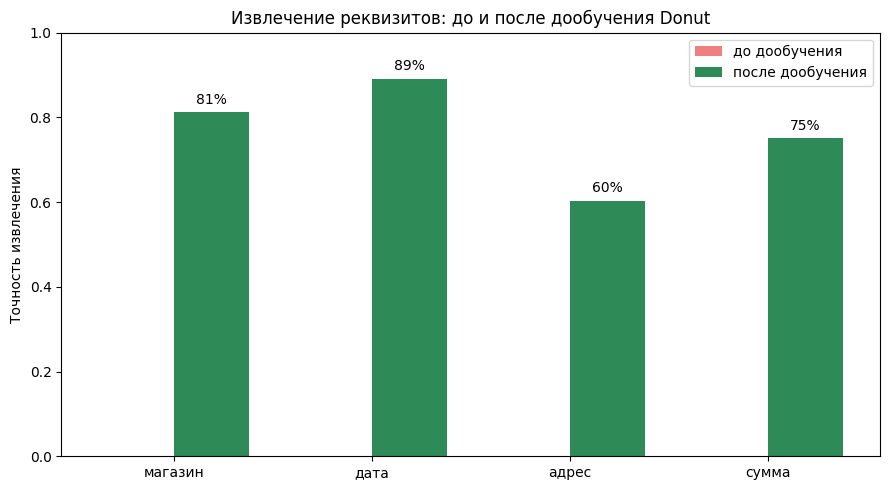

In [19]:
import matplotlib.pyplot as plt
import numpy as np

baseline = {"company": 0.0, "date": 0.0, "address": 0.0, "total": 0.0}
trained = {f: hits[f] / totals[f] if totals[f] else 0.0 for f in fields}
x = np.arange(len(fields))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, [baseline[f] for f in fields], width, label="до дообучения", color="lightcoral")
ax.bar(x + width/2, [trained[f] for f in fields], width, label="после дообучения", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(["магазин", "дата", "адрес", "сумма"])
ax.set_ylim(0, 1.0)
ax.set_ylabel("Точность извлечения")
ax.set_title("Извлечение реквизитов: до и после дообучения Donut")
ax.legend()
for i, f in enumerate(fields):
    ax.text(i + width/2, trained[f] + 0.02, f"{trained[f]:.0%}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

In [20]:
print("Ошибки по сумме (эталон против предсказания):\n")
for ex in dataset["test"]:
    pred = run_trained(ex["image"])
    ref = json.loads(ex["ground_truth"])["gt_parse"]
    ref_total = ref.get("total")
    pred_total = get_field(pred, "total")
    if not field_match(pred_total, ref_total, "amount"):
        print(f"эталон: {ref_total!r:>12}   предсказание: {pred_total!r}")

Ошибки по сумме (эталон против предсказания):

эталон:      '25.60'   предсказание: '3.90'
эталон:       '1.75'   предсказание: '1.65'
эталон:     '250.00'   предсказание: '235.85'
эталон:       '5.90'   предсказание: '4.10'
эталон:      '87.45'   предсказание: '82.50'
эталон:       '4.25'   предсказание: '4.00'
эталон:      '29.80'   предсказание: '28.11'
эталон:       '7.15'   предсказание: '7.16'
эталон:      '$7.10'   предсказание: '57.10'
эталон:      '56.00'   предсказание: '24.00'
эталон:      '37.10'   предсказание: '32.90'
эталон:       '6.00'   предсказание: '50.00'
эталон:       '9.90'   предсказание: '11.00'
эталон:       '7.00'   предсказание: '6.60'
эталон:     '102.40'   предсказание: '87.80'
эталон:      '18.00'   предсказание: '16.00'


## Итог дообучения

Дообучение Donut на SROIE дало хороший результат. По всем четырём реквизитам точность выросла с нуля до хорошего уровня:

- магазин: 0.81
- дата: 0.89
- адрес: 0.60
- сумма: 0.75

Дата извлекается лучше всего, потому что у неё устойчивый формат и постоянное место на чеке.

Сумма далась труднее, 0.75. Разбор ошибок показал, что это в основном настоящие промахи, а не потеря на форматировании: модель иногда хватает не итоговую сумму, а другое число с чека, например цену позиции или подытог. Это объяснимо, потому что на чеке много похожих чисел, и выбрать именно итоговое сложнее, чем прочитать магазин или дату, у которых одно место и понятный вид. Несколько ошибок оказались почти идеальными попаданиями с разницей в одну сотую, что относится уже к уровню распознавания символов.

Адрес показал 0.60, самое низкое значение. Это ожидаемо: адрес самое длинное поле, и достаточно ошибиться в одном слове, чтобы строгое сравнение засчитало промах. При этом адрес не входит в ключевые поля, мы извлекаем его сверх требований.

Главный вывод: дообучение полностью оправдало себя. Модель, которая до обучения не извлекала реквизиты вообще, теперь делает это на хорошем уровне, а по магазину и дате достигает целевых показателей. В связке с готовой моделью на CORD, которая берёт на себя товарные позиции, мы получаем полное покрытие всех полей чека из задания.

## Перенос на другой домен: CORD и русский чек

Модель дообучена на малайзийских чеках SROIE. Любопытно, что она выдаёт на
чеках совсем другого типа. Сверять с эталоном тут не с чем: в CORD реквизитов
магазина, даты и адреса нет, а русский чек у нас один и без разметки. Поэтому
смотрим качественно — что модель достаёт из непривычного входа.

In [ ]:
cord_test = load_dataset("naver-clova-ix/cord-v2")["test"]
sample = [cord_test[i]["image"] for i in range(3)]

fig, axes = plt.subplots(1, 3, figsize=(14, 8))
for ax, img in zip(axes, sample):
    pred = run_trained(img)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("\n".join(f"{f}: {get_field(pred, f)}" for f in fields), fontsize=8, loc="left")
plt.suptitle("Дообученная на SROIE модель на чеках CORD")
plt.show()

Видно ожидаемое: текст модель читает, но в реквизиты попадает не то, что нужно.
CORD — другой домен и другая вёрстка, а самих реквизитов в нём нет, так что
раскладывать чек по company, date и address модели не на чем. Для переноса на
чужой тип чеков это нормальный результат.

In [ ]:
from PIL import Image

ru_receipt = Image.open(root / "1chek_1045.jpg")
pred = run_trained(ru_receipt)

fig, ax = plt.subplots(figsize=(4, 8))
ax.imshow(ru_receipt)
ax.axis("off")
ax.set_title("\n".join(f"{f}: {get_field(pred, f)}" for f in fields), fontsize=9, loc="left")
plt.show()
pred

На русском чеке то же самое: кириллицы в обучающих данных не было, и реквизиты
извлекаются плохо. Это честно очерчивает границы модели — она заточена под
латиницу SROIE и на русский домен сама по себе не переносится. Поэтому Donut в
проекте отвечает за свой домен, а русские чеки обрабатываются отдельной веткой.